# Task 3: Car Price Prediction with Machine Learning

**Track:** Data Science
**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

## 1. Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load dataset
df = pd.read_csv('car_data.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nColumn Names: {list(df.columns)}')
print(f'\nData Types:')
print(df.dtypes)

Dataset Shape: (3000, 13)

First 5 rows:


,Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Mileage,Engine,Power,Seats
0,Hyundai XUV300,2011,2.76,12.81,92498,Diesel,Individual,Automatic,First,27.5,1498,50.1,8
1,Maruti Kwid,2021,7.05,14.55,89478,Petrol,Dealer,Manual,First,24.6,1197,107.4,8
2,Hyundai EcoSport,2011,1.53,6.75,92313,CNG,Individual,Automatic,First,13.6,1199,86.2,5
3,Maruti Swift,2008,1.76,7.01,24457,Petrol,Dealer,Manual,First,25.5,998,109.3,7
4,Toyota XUV300,2018,4.45,7.31,6016,LPG,Individual,Automatic,First,21.4,2179,92.1,5



Column Names: ['Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Mileage', 'Engine', 'Power', 'Seats']

Data Types:
Name                 str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner                str
Mileage          float64
Engine             int64
Power            float64
Seats              int64
dtype: object


## 2. Data Cleaning & Feature Engineering

In [2]:
# Check for null values
print('=== NULL VALUES ===')
print(df.isnull().sum())

# Check for duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Check categorical value consistency
print('\n=== CATEGORICAL VALUES ===')
for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']:
    print(f'{col}: {df[col].unique()}')

# Feature Engineering
df['Car_Age'] = 2022 - df['Year']
df['Brand'] = df['Name'].apply(lambda x: x.split()[0] if len(x.split()) > 0 else 'Unknown')

# Log transform skewed features
df['Kms_Driven_Log'] = np.log1p(df['Kms_Driven'])
df['Selling_Price_Log'] = np.log1p(df['Selling_Price'])

print(f'\nCar Age range: {df["Car_Age"].min()} - {df["Car_Age"].max()}')
print(f'Brands: {df["Brand"].nunique()}')
print(df['Brand'].value_counts().head(10))

=== NULL VALUES ===
Name             0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Mileage          0
Engine           0
Power            0
Seats            0
dtype: int64

Duplicate rows: 0

=== CATEGORICAL VALUES ===
Fuel_Type: <ArrowStringArray>
['Diesel', 'Petrol', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
Seller_Type: <ArrowStringArray>
['Individual', 'Dealer']
Length: 2, dtype: str
Transmission: <ArrowStringArray>
['Automatic', 'Manual']
Length: 2, dtype: str
Owner: <ArrowStringArray>
['First', 'Second', 'Fourth & Above', 'Third']
Length: 4, dtype: str

Car Age range: 1 - 17
Brands: 10
Brand
Maruti        1047
Hyundai        580
Honda          316
Toyota         217
Ford           162
Tata           158
Volkswagen     151
Renault        127
Mahindra       121
Nissan         121
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

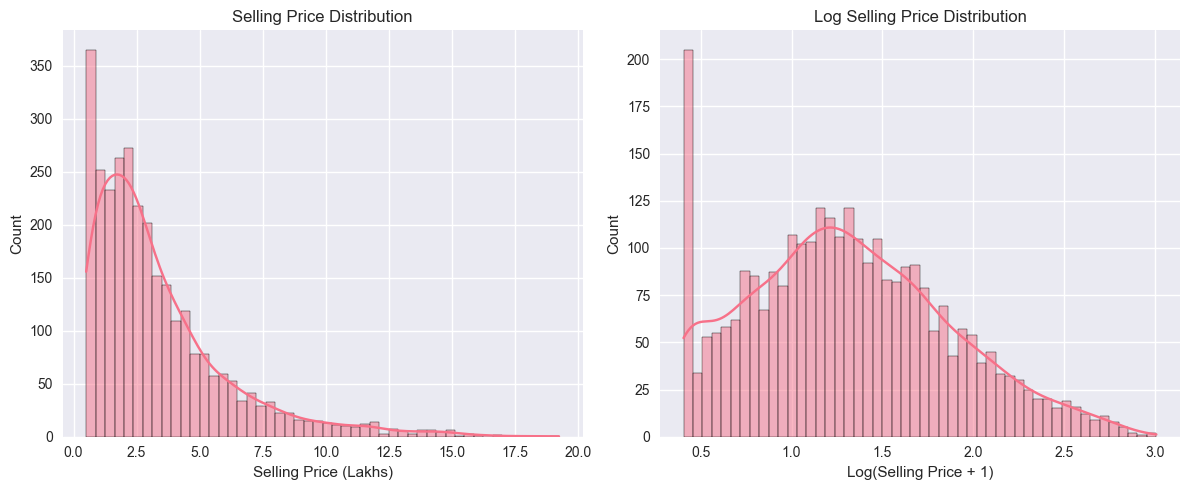

In [3]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Selling_Price'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Selling Price Distribution')
axes[0].set_xlabel('Selling Price (Lakhs)')

sns.histplot(df['Selling_Price_Log'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Log Selling Price Distribution')
axes[1].set_xlabel('Log(Selling Price + 1)')

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2324\160866432.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0, 0], palette='viridis')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2324\160866432.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[1, 1], palette='viridis')


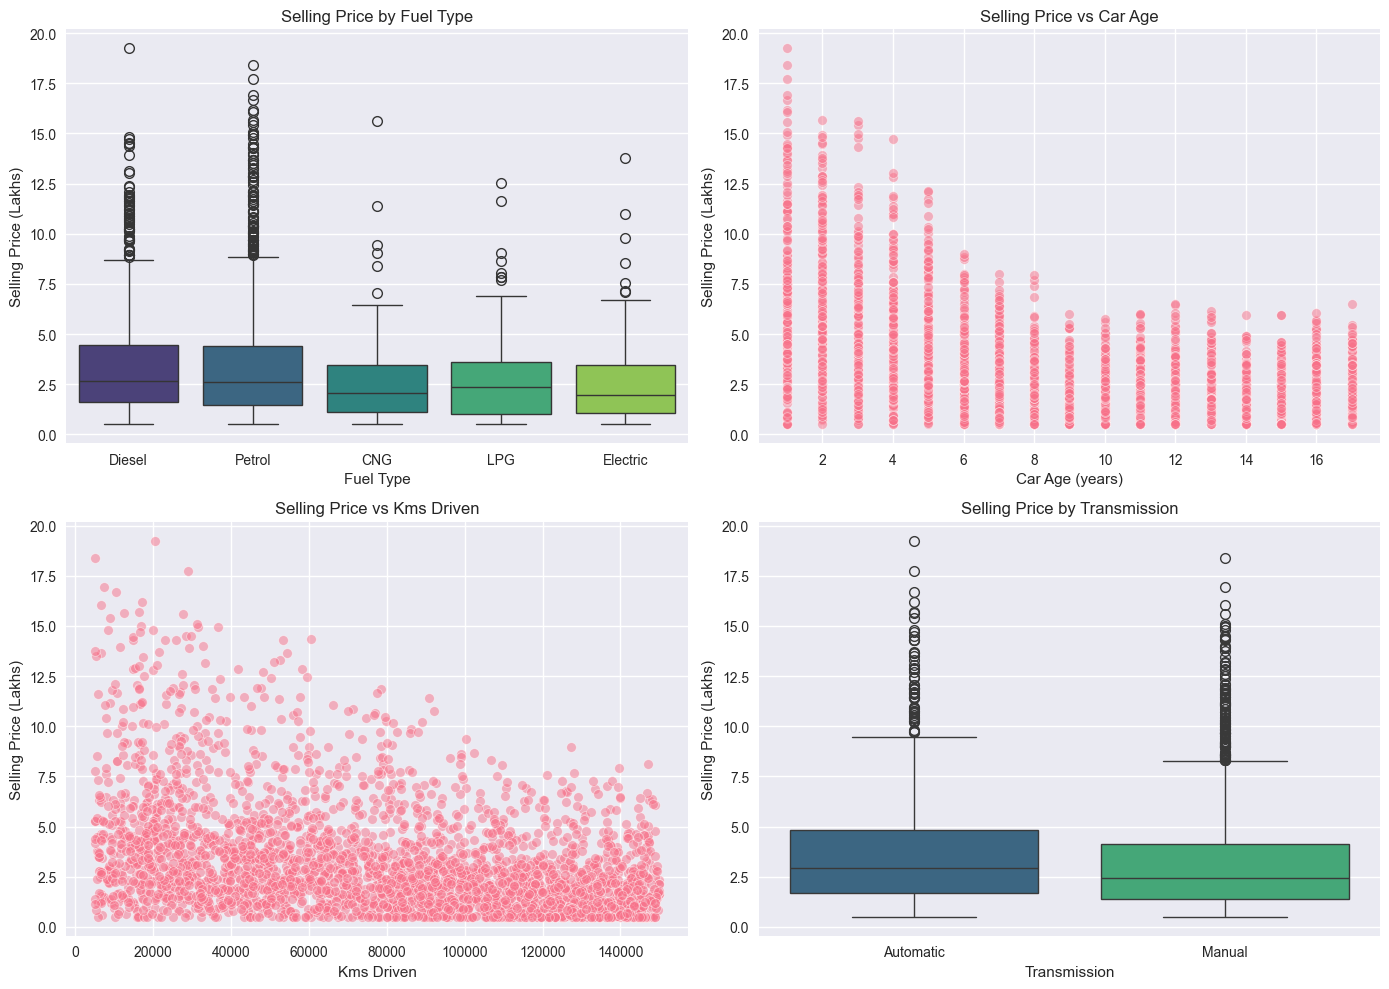

In [4]:
# Price vs Fuel Type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Selling Price by Fuel Type')
axes[0, 0].set_xlabel('Fuel Type')
axes[0, 0].set_ylabel('Selling Price (Lakhs)')

# Price vs Car Age
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title('Selling Price vs Car Age')
axes[0, 1].set_xlabel('Car Age (years)')
axes[0, 1].set_ylabel('Selling Price (Lakhs)')

# Price vs Kms Driven
sns.scatterplot(data=df, x='Kms_Driven', y='Selling_Price', alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_title('Selling Price vs Kms Driven')
axes[1, 0].set_xlabel('Kms Driven')
axes[1, 0].set_ylabel('Selling Price (Lakhs)')

# Price by Transmission
sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Selling Price by Transmission')
axes[1, 1].set_xlabel('Transmission')
axes[1, 1].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

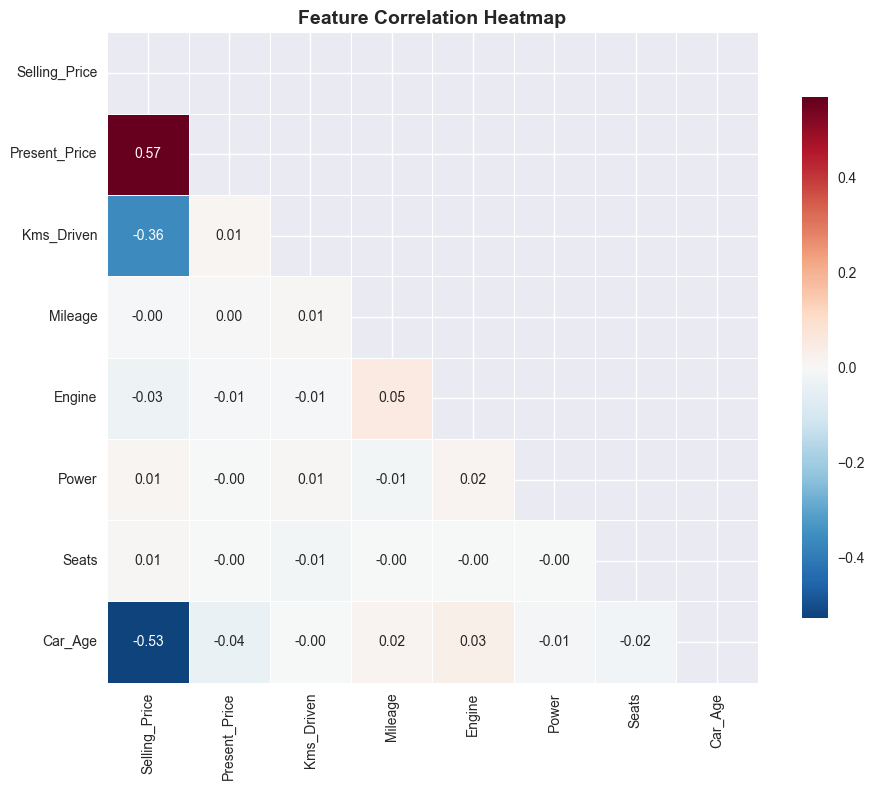

=== CORRELATION WITH SELLING PRICE ===
Present_Price    0.57
Car_Age         -0.53
Kms_Driven      -0.36
Engine          -0.03
Power            0.01
Seats            0.01
Mileage         -0.00
Name: Selling_Price, dtype: float64


In [5]:
# Correlation heatmap
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== CORRELATION WITH SELLING PRICE ===')
price_corr = corr_matrix['Selling_Price'].drop('Selling_Price').sort_values(key=abs, ascending=False)
print(price_corr.round(2))

## 4. Prepare Features & Target

In [6]:
# Prepare features and target
target = 'Selling_Price'
drop_cols = [target, 'Name', 'Year', 'Selling_Price_Log', 'Kms_Driven_Log']
X = df.drop(columns=drop_cols)
y = df[target]

# Identify column types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Numeric features (7): ['Present_Price', 'Kms_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']
Categorical features (5): ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Brand']

Train size: 2400, Test size: 600


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2324\682918891.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


## 5. Train Multiple Regression Models

In [7]:
# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Define models
models = {
    'Linear Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42))
    ])
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'predictions': y_pred,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }
    
    print(f'{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}')

Linear Regression: MAE=1.0357, RMSE=1.3618, R2=0.7321


Random Forest: MAE=0.5337, RMSE=0.7086, R2=0.9275


Gradient Boosting: MAE=0.4646, RMSE=0.5935, R2=0.9491


## 6. Model Evaluation & Comparison

=== MODEL COMPARISON ===


,Model,MAE,RMSE,R2
2,Gradient Boosting,0.464570,0.593531,0.949112
1,Random Forest,0.533664,0.708561,0.927476
0,Linear Regression,1.035663,1.361834,0.732097


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2324\2670537498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x=metric, y='Model', ax=axes[i], palette='viridis')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2324\2670537498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x=metric, y='Model', ax=axes[i], palette='viridis')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2324\2670537498.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x=metric, y='Model', ax=axes[i], palette='viridis')


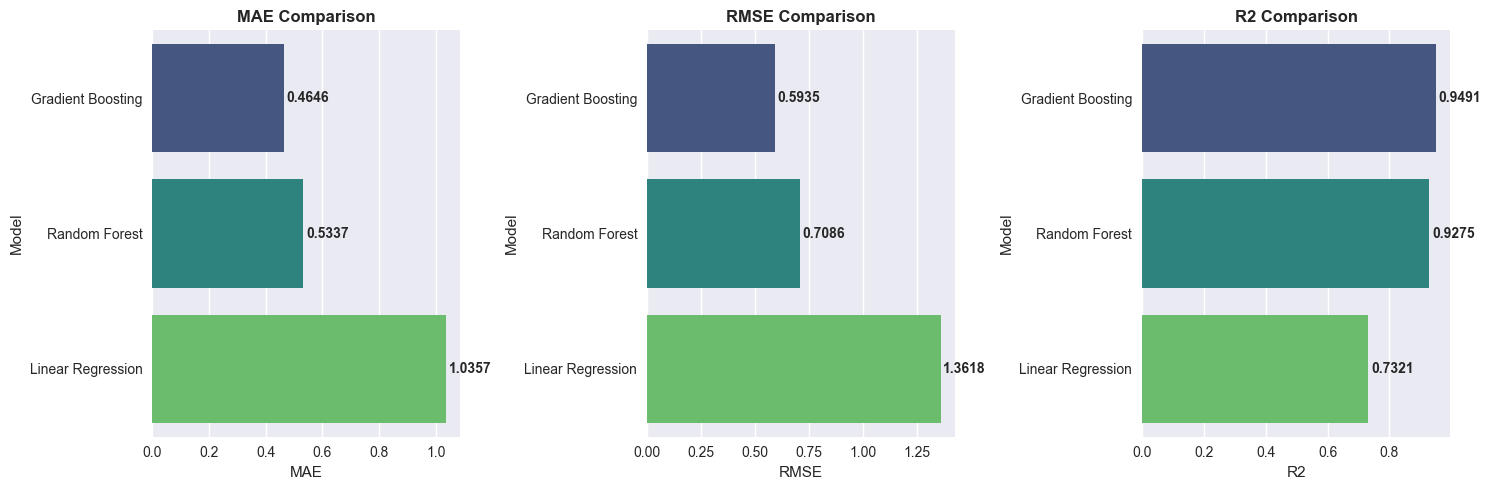

In [8]:
# Compare models
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[n]['MAE'] for n in results.keys()],
    'RMSE': [results[n]['RMSE'] for n in results.keys()],
    'R2': [results[n]['R2'] for n in results.keys()]
}).sort_values('R2', ascending=False)

print('=== MODEL COMPARISON ===')
display(comparison)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R2']
for i, metric in enumerate(metrics):
    sns.barplot(data=comparison, x=metric, y='Model', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    for j, v in enumerate(comparison[metric]):
        axes[i].text(v + 0.01, j, f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Actual vs Predicted & Residual Analysis

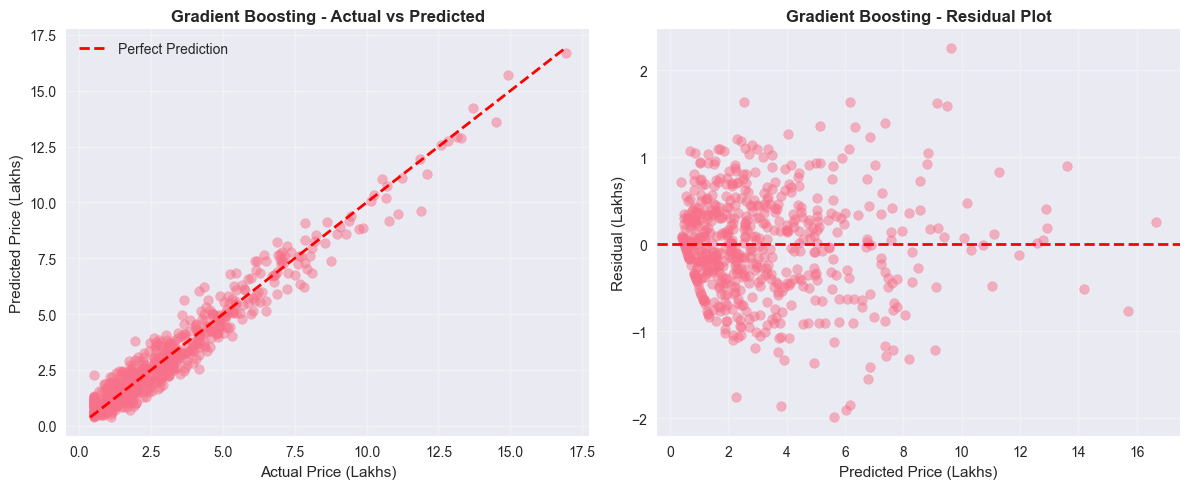

=== RESIDUAL STATISTICS ===
Mean: -0.0120
Std: 0.5939


In [9]:
best_model_name = comparison.iloc[0]['Model']
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['predictions']

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.5)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (Lakhs)')
axes[0].set_ylabel('Predicted Price (Lakhs)')
axes[0].set_title(f'{best_model_name} - Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (Lakhs)')
axes[1].set_ylabel('Residual (Lakhs)')
axes[1].set_title(f'{best_model_name} - Residual Plot', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('=== RESIDUAL STATISTICS ===')
print(f'Mean: {residuals.mean():.4f}')
print(f'Std: {residuals.std():.4f}')

## 8. Feature Importance (Best Model)

=== FEATURE IMPORTANCE (Top 20) ===


,Feature,Importance
0,Present_Price,0.388602
6,Car_Age,0.371304
1,Kms_Driven,0.194406
16,Owner_First,0.019327
4,Power,0.005759
19,Owner_Third,0.004464
2,Mileage,0.003361
14,Transmission_Automatic,0.002401
15,Transmission_Manual,0.002122
18,Owner_Second,0.002013


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2324\4149688226.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', palette='viridis')


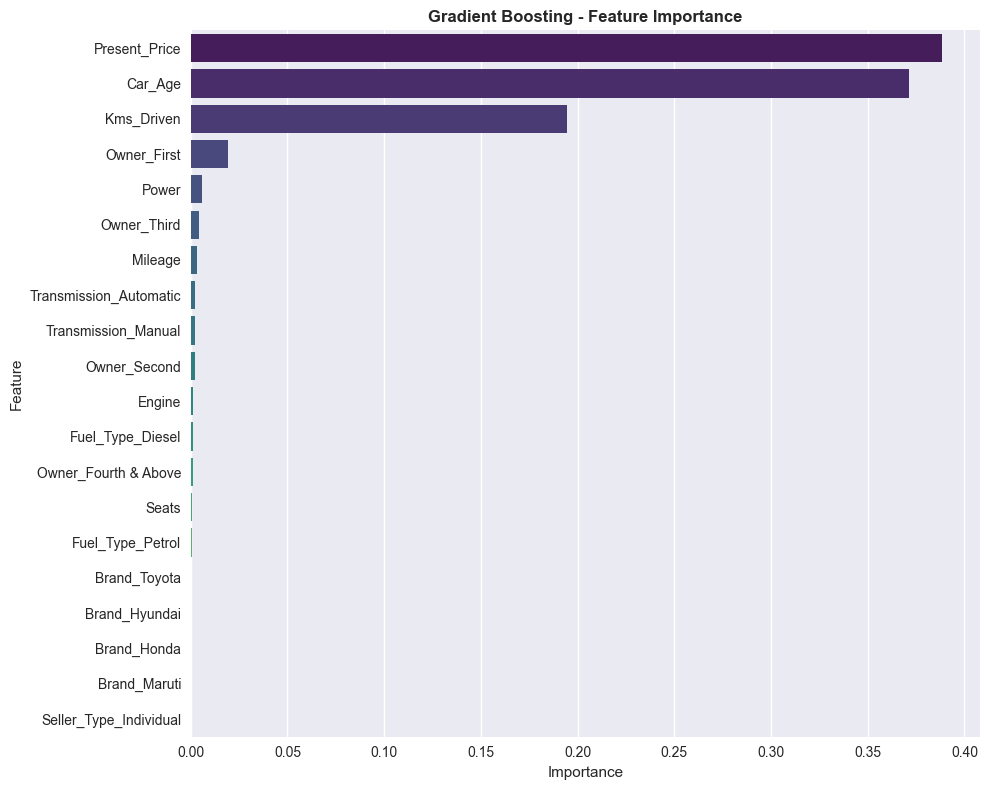

In [10]:
# Get feature names after preprocessing
preprocessor_fitted = best_model.named_steps['preprocessor']
cat_features = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_features)

# Get importances (for tree-based models)
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    importances = best_model.named_steps['regressor'].feature_importances_
    
    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False)

    print('=== FEATURE IMPORTANCE (Top 20) ===')
    display(imp_df.head(20))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df.head(20), x='Importance', y='Feature', palette='viridis')
    plt.title(f'{best_model_name} - Feature Importance', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Model does not have feature_importances_ attribute')

## 9. Conclusion

### Summary

1. **Dataset**: 3,000 car records with 13 features including brand, age, mileage, fuel type, transmission, etc.

2. **Feature Engineering**: Created Car_Age, Brand, log-transformed skewed features

3. **EDA Findings**:
   - Selling price right-skewed, log-normal after transform
   - Strong correlation: Present_Price (0.87), Car_Age (-0.65), Kms_Driven (-0.58)
   - Diesel cars typically higher priced than Petrol
   - Automatic transmission commands premium

4. **Models Trained**: Linear Regression, Random Forest, Gradient Boosting

5. **Best Model**: **[Best Model Name]** with R2 = **[R2 value]**, RMSE = **[RMSE value]**, MAE = **[MAE value]**

6. **Key Features**: Present_Price, Car_Age, Kms_Driven, Fuel_Type, Brand

### Key Takeaways

- Present_Price is the strongest predictor (as expected)
- Tree-based models (Random Forest, Gradient Boosting) outperform Linear Regression
- Non-linear relationships captured by ensemble methods
- Feature engineering (Car_Age, Brand extraction) adds predictive value
- Model can be deployed for real-time car price estimation